In [ ]:
import pandas as pd #mobile change
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings   # The warnings module is a built-in Python library that handles warning messages.
warnings.filterwarnings('ignore')  # This tells Python to suppress/hide all warning messages during your session.
plt.style.use('seaborn-v0_8')  # seaborn-v0_8 gives your charts a clean, grid-based look with muted colors — much nicer than matplotlib's 

In [ ]:
df = pd.read_csv('../datasets/city_day.csv')
df.head

<bound method NDFrame.head of                 City        Date  PM2.5   PM10     NO    NO2    NOx    NH3  \
0          Ahmedabad  2015-01-01    NaN    NaN   0.92  18.22  17.15    NaN   
1          Ahmedabad  2015-01-02    NaN    NaN   0.97  15.69  16.46    NaN   
2          Ahmedabad  2015-01-03    NaN    NaN  17.40  19.30  29.70    NaN   
3          Ahmedabad  2015-01-04    NaN    NaN   1.70  18.48  17.97    NaN   
4          Ahmedabad  2015-01-05    NaN    NaN  22.10  21.42  37.76    NaN   
...              ...         ...    ...    ...    ...    ...    ...    ...   
29526  Visakhapatnam  2020-06-27  15.02  50.94   7.68  25.06  19.54  12.47   
29527  Visakhapatnam  2020-06-28  24.38  74.09   3.42  26.06  16.53  11.99   
29528  Visakhapatnam  2020-06-29  22.91  65.73   3.45  29.53  18.33  10.71   
29529  Visakhapatnam  2020-06-30  16.64  49.97   4.05  29.26  18.80  10.03   
29530  Visakhapatnam  2020-07-01  15.00  66.00   0.40  26.85  14.05   5.20   

          CO    SO2      O3  Benz

In [ ]:
print("Shape:", df.shape)

Shape: (29531, 16)


In [ ]:
# Data types and info of dataset:-
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


Key Insights 

1. Columns Types:- 
    -  13 numeric columns (float64) — all the pollutant measurements like PM2.5, PM10, NO, NO2, CO, SO2, O3, Benzene, Toluene, Xylene, AQI etc
    -  3 text columns (object) — City, Date, and AQI_Bucket


2. Missing Values:- 
    Every pollutant column has missing data.
    -  Xylene = 8,109 missing (biggest gap)
    -  Toluene = 9,041 missing
    -  NH3 = 10,328 missing
    -  Benzene = 5,623 missing
    -  PM10 = 11,140 missing
    -  AQI = 4,681 missing
    -  PM2.5 = 4,598 missing
    -  City & Date have zero missing values 
    

In [ ]:
# Statistical summary of the dataset:-
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


Key Insights
1) General Observation:-
    - Count varies across columns — confirms the missing values in the dataset
    - CO has the highest count (27,472) —> least missing
    - Xylene has the lowest count (11,422) —> most missing

2)  Skewness Check:- 
    - PM2.5: Mean = 67.45 and Median = 48.57 -> Mean >> Median → right skewed
    - PM10: Mean = 118.13 and Median = 95.68 -> Mean >> Median → right skewed
    - AQI: Mean = 166.46 and Median = 118.00 -> Mean >> Median → heavily right skewed
    - Toluene: Mean = 8.70 and Median = 2.97 -> Mean >> Median → very right skewed
 
    Almost all columns are right skewed — meaning there are high pollution spike values pulling the mean up.
    Also, standard deviations are very high relative to means — data is widely spread, not consistent


In [ ]:
# Check missing values
missing = df.isnull().sum()  # df.isnull() -> creates a True/False table for every cell (True = missing, False = not missing) and .sum() → counts all the Trues (missing values) for each column
missing_pct = (missing / len(df)) * 100 # Divides missing count by total rows and multiplies by 100 -> Gives you the percentage of missing values per column
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Values'] > 0])

            Missing Values  Percentage
PM2.5                 4598   15.570079
PM10                 11140   37.723071
NO                    3582   12.129626
NO2                   3585   12.139785
NOx                   4185   14.171549
NH3                  10328   34.973418
CO                    2059    6.972334
SO2                   3854   13.050692
O3                    4022   13.619586
Benzene               5623   19.041008
Toluene               8041   27.229014
Xylene               18109   61.322001
AQI                   4681   15.851139
AQI_Bucket            4681   15.851139


Key insights:-
1) df.isnull() → creates a True/False table for every cell (True = missing, False = not missing) while, .sum() → counts all the Trues (missing values) for each column.
2) missing_pct → Divides missing count by total rows and multiplies by 100, this gives us the percentage of missing values per column.
3) missing_df → Combines both — the 'Count' and 'Percentage' — into a neat single DataFrame and named the two columns as: "Missing Values" and "Percentage".
4) print(missing_df[missing_df['Missing Values'] > 0]) → Filters and shows only columns that have at least 1 missing value, columns with zero missing (like City, Date) are excluded from output.


All this keeps the output clean and relevant and makes it easy to read and compare

From the table we can observe that 
   - Xylene is 61% missing
   - PM10, NH3 and Toluene are also heavily missing ( 27–38% )
   - PM2.5, NOx, AQI, SO2, O3, Benzene are moderately missing ( 13–19% )
   - CO, NO, NO2 are relatively clean ( 7–12% )

In [ ]:
# Handle missing values — fill with column mean
df['PM2.5'].fillna(df['PM2.5'].median(), inplace=True)
df['PM10'].fillna(df['PM10'].median(), inplace=True)

Key insights: 
1) Calculates Median of all existing PM2.5 values and fills every missing PM2.5 value with the median of PM2.5, simillarly for PM10
2) Our air quality data is skewed so we prefer Median over mean for imputation here.
   - Data is normally distributed → use Mean
   - Data is skewed or has outliers → use Median


In [ ]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Season'] = df['Month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
})

print("Data cleaned successfully!")
print("Shape after cleaning:", df.shape)

Data cleaned successfully!
Shape after cleaning: (29531, 19)


Key Insights:- 
1) Date conversion:- Converted Date from plain text → proper datetime object
2) Year and Month extraction:- New column "Year" (2018, 2019, 2020...) and "Month" (1,2,3,...,12) are created.
3) Season mapping: New column Season created based on month: 

   - Month: [12, 1, 2] -> Winter
   - Month: [3, 4, 5] -> Spring
   - Month: [6, 7, 8] -> Summer
   - Month: [9, 10, 11] -> Autumn

Observation:- 

4) Three  powerful new features added — enables time based analysis. These new columns allow you to now ask questions like:

   - Which season has worst air quality?
   - Is pollution getting worse year by year?
   - Which month has highest PM2.5?

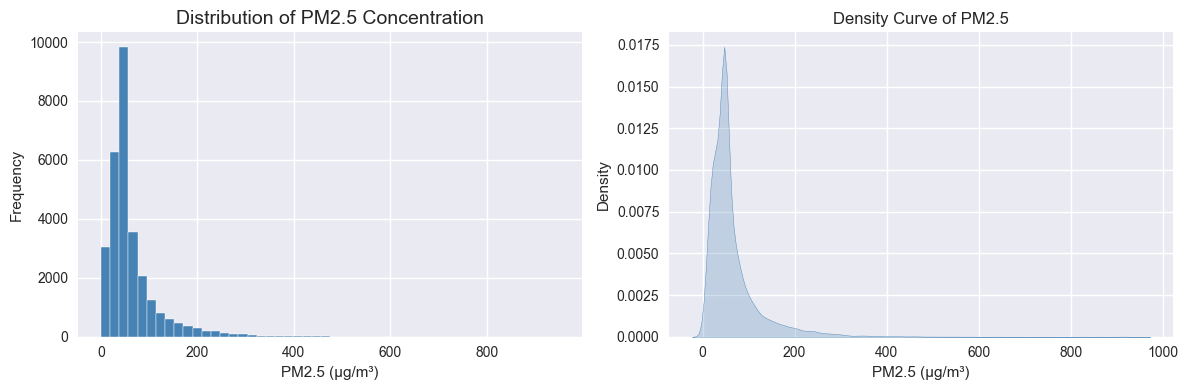

Observation: PM2.5 shows a right-skewed distribution,
indicating most readings are low but some extreme
pollution events pull the tail to the right.


In [ ]:
# Plot 1 — Distribution of PM2.5
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Histogram
axes[0].hist(df['PM2.5'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of PM2.5 Concentration', fontsize=14)
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Frequency')

# KDE plot
sns.kdeplot(df['PM2.5'].dropna(), ax=axes[1], color='steelblue', fill=True)
axes[1].set_title('Density Curve of PM2.5', fontsize=12)
axes[1].set_xlabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()
print("Observation: PM2.5 shows a right-skewed distribution,")
print("indicating most readings are low but some extreme")
print("pollution events pull the tail to the right.")

Key Insights:- 

1) Setup: Creates 1 row, 2 columns of plots side by side where the figure size is 14 inches wide and 5 inches tall.

2) Left Plot — Histogram:
   - .dropna() → removes any remaining NaN values before plotting
   - bins=50 → divides data into 50 bars
   - color='steelblue' → bar fill color
   - edgecolor='white' → white border between bars for clarity
   - and then just adding title, x label and y label to the left plot.

3) Right Plot — KDE:
   - kdeplot → Kernel Density Estimate — a smooth curve version of histogram
   - ax=axes[1] → plot on the right side
   - ax=axes[1] → plot on the right side
   - and then just adding title and x label to the right plot.

4) Final Lines:
   - tight_layout() → auto adjusts spacing so plots don't overlap
   - show() → displays the plots

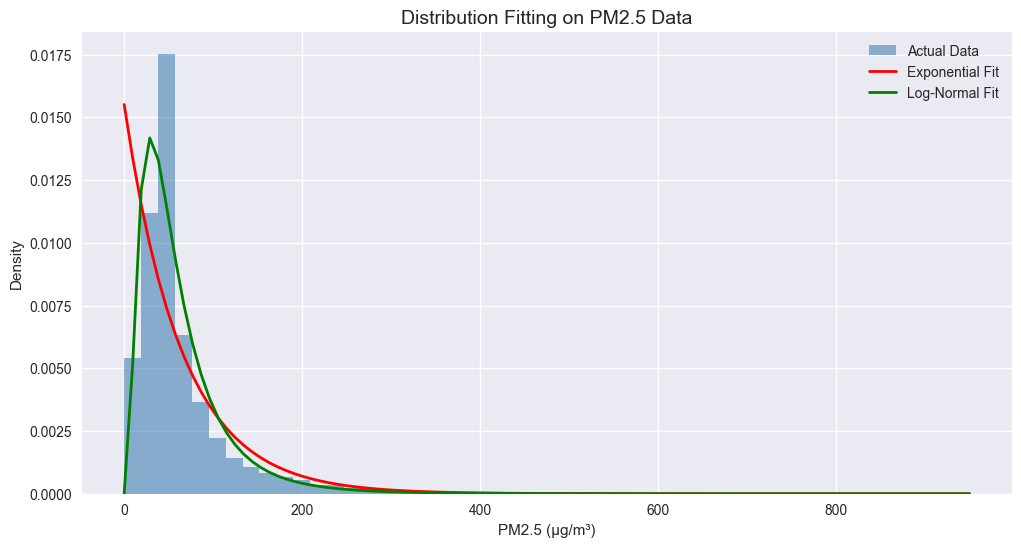

Observation: Log-Normal distribution fits PM2.5 data
better than Exponential, consistent with literature
on environmental pollutant concentrations.


In [ ]:
# Plot 2 — Distribution fitting 
pm25_clean = df['PM2.5'].dropna()
fig, ax = plt.subplots(figsize=(12, 6))

# Plot actual data distribution
ax.hist(pm25_clean, bins=50, density=True, alpha=0.6, color='steelblue', label='Actual Data')

# Fit and plot distributions
x = np.linspace(pm25_clean.min(), pm25_clean.max(), 100)

# Exponential fit
loc_e, scale_e = stats.expon.fit(pm25_clean)
ax.plot(x, stats.expon.pdf(x, loc_e, scale_e), 'r-', lw=2, label='Exponential Fit')

# Log-normal fit
shape_l, loc_l, scale_l = stats.lognorm.fit(pm25_clean)
ax.plot(x, stats.lognorm.pdf(x, shape_l, loc_l, scale_l), 'g-', lw=2, label='Log-Normal Fit')

ax.set_title('Distribution Fitting on PM2.5 Data', fontsize=14)
ax.set_xlabel('PM2.5 (µg/m³)')
ax.set_ylabel('Density')
ax.legend()
plt.show()
print("Observation: Log-Normal distribution fits PM2.5 data")
print("better than Exponential, consistent with literature")
print("on environmental pollutant concentrations.")

Key Insights:-

1) Setup: dropna() → removes any missing values from PM2.5 and then creates a single plot of size 10x5.
2) Actual Data Histogram:
   - density=True → converts frequency to density (so it can be compared with fitted curves)
   - alpha=0.6 → makes bars 60% transparent so curves are visible on top
3) x = np.linspace(pm25_clean.min(), pm25_clean.max(), 100): Creates 100 evenly spaced points from min to max of PM2.5 and used as x axis values to draw smooth fitted curves
4) Exponential Fit (Red curve):
   - stats.expon.fit() → automatically finds best exponential distribution parameters for your data
   - loc_e → starting point of distribution
   - scale_e → how spread out it is
   - .pdf() → calculates the probability density at each x point
   - 'r-' → red solid line, lw=2 → line width 2

5) Log-Normal Fit (Green curve):
   - stats.lognorm.fit() → finds best log-normal distribution parameters
   - shape_l → controls the shape/skewness
   - Same plotting logic as exponential but green color
6) Final lines: Just adding labels, title, legend and displaying the plot.


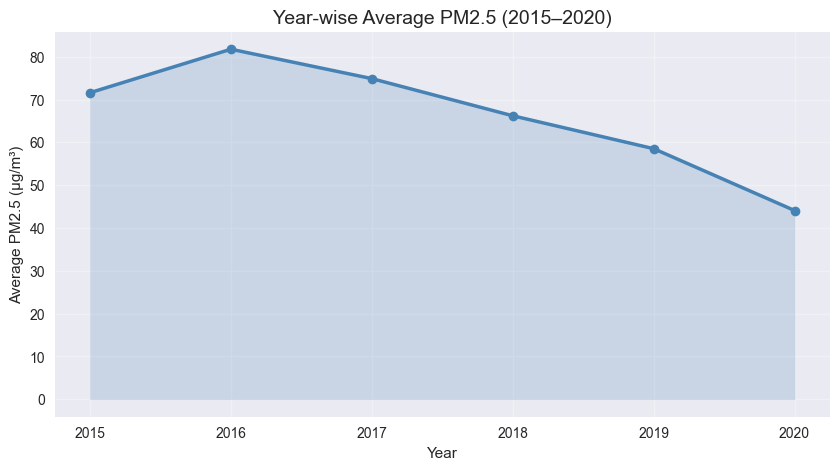

Observation: Note any increasing/decreasing trend


In [ ]:
# Plot 3 — Yearly trend
yearly_avg = df.groupby('Year')['PM2.5'].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o', color='steelblue', linewidth=2.5)
plt.fill_between(yearly_avg.index, yearly_avg.values, alpha=0.2, color='steelblue')
plt.title('Year-wise Average PM2.5 (2015–2020)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.grid(True, alpha=0.3)
plt.show()
print("Observation: Note any increasing/decreasing trend")

Key Insights:-

1) Data Preparation.

2) Figure size: Creates a plot of size 10 inches wide, 5 inches tall.

3) Line Plot: 
   - yearly_avg.index → x axis = years (2015, 2016...) 
   - yearly_avg.values → y axis = average PM2.5 values
   - marker='o' → adds a circle dot at each data point
   - linewidth=2.5 → line thickness

4)  Shaded Area: 
   - Fills the area under the line with steelblue color
   - alpha=0.2 → only 20% opacity — light shading
   - Makes the trend visually more appealing and easier to read

5) Final Lines: plt.grid(True, alpha=0.3) → adds light grid lines at 30% opacity for readability


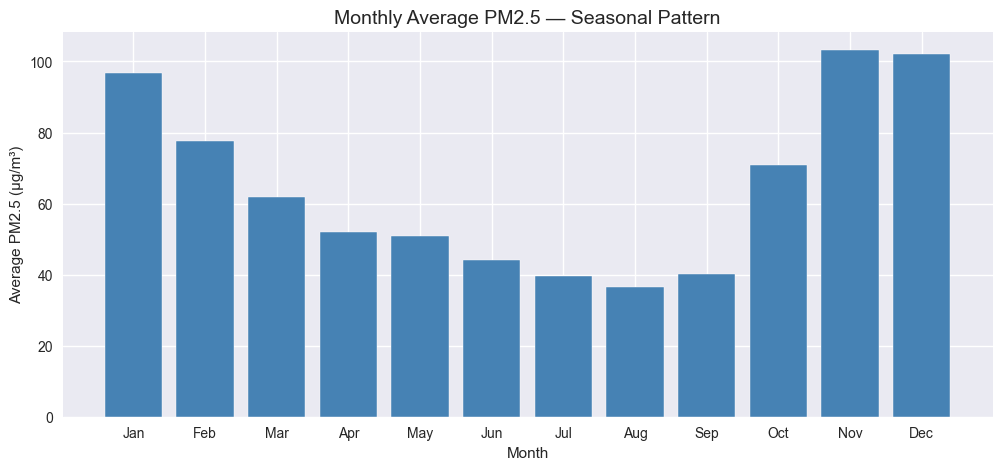

Observation: PM2.5 peaks in winter months (Nov-Jan)
and drops in monsoon (Jun-Aug) — consistent with
reduced wind speed and increased biomass burning
in winter.


In [ ]:
# Plot 4 — Monthly seasonality
monthly_avg = df.groupby('Month')['PM2.5'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
plt.bar(months, monthly_avg.values, color='steelblue', edgecolor='white')
plt.title('Monthly Average PM2.5 — Seasonal Pattern', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.show()
print("Observation: PM2.5 peaks in winter months (Nov-Jan)")
print("and drops in monsoon (Jun-Aug) — consistent with")
print("reduced wind speed and increased biomass burning")
print("in winter.")

Key Insights:- 

1) Data Preparation

2) Month Labels: Creates a list of month name labels which are used to replace number labels (1,2,3...) with readable names on x axis.

3) Figure & Bar Plot:
   - figsize=(12, 5) → wider plot to fit all 12 months
   - plt.bar() → creates a bar chart
   - months → x axis labels
   - monthly_avg.values → height of each bar = average PM2.5
   - edgecolor='white' → white border between bars for clarity

4) Final Lines: Lables -> Standard title and axis labels

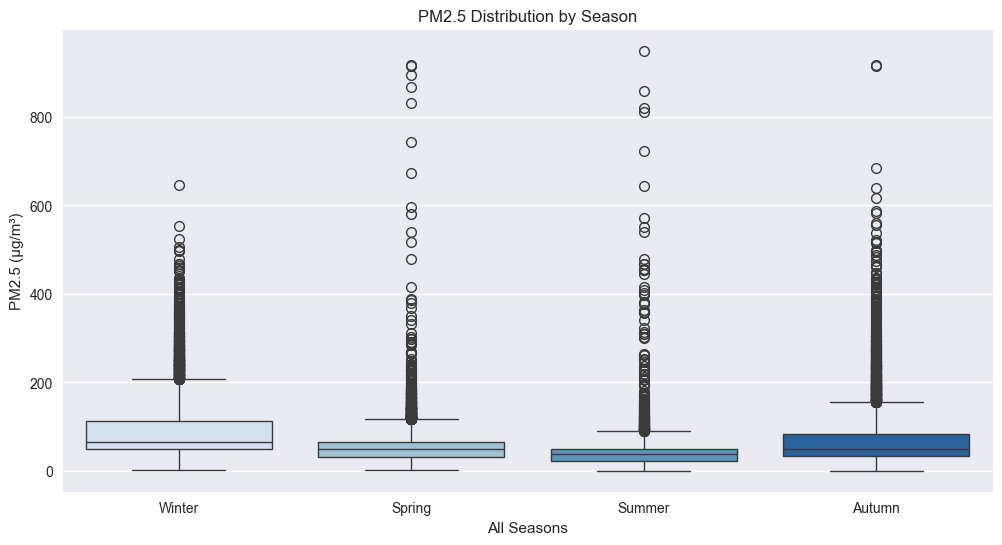

In [ ]:
# Plot 5 — Seasonal boxplot
plt.figure(figsize=(12, 6))
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
sns.boxplot(x='Season', y='PM2.5', data=df, order=season_order, palette='Blues')
plt.title('PM2.5 Distribution by Season', fontsize=12)
plt.xlabel('All Seasons')
plt.ylabel('PM2.5 (µg/m³)')
plt.show()

Key Insights:- 
1) Figure size: Creates a plot of size 10 wide, 6 tall.

2) Season Order: Defines the order in which seasons appear on x axis without this, seaborn might plot them alphabetically — Autumn, Spring, Summer, Winter which doesn't make logical sense.

3) Boxplot:
   - x='Season' → x axis = season categories
   - y='PM2.5' → y axis = PM2.5 values
   - data=df → use the main dataframe
   - data=df → use the main dataframe
   - palette='Blues' → different shades of blue for each season box

4) Final Lines:  Labels->
   - Box height = how spread out middle 50% of data is
   - Median line = middle value
   - Whiskers = range of normal values
   - Circles = outliers beyond normal range


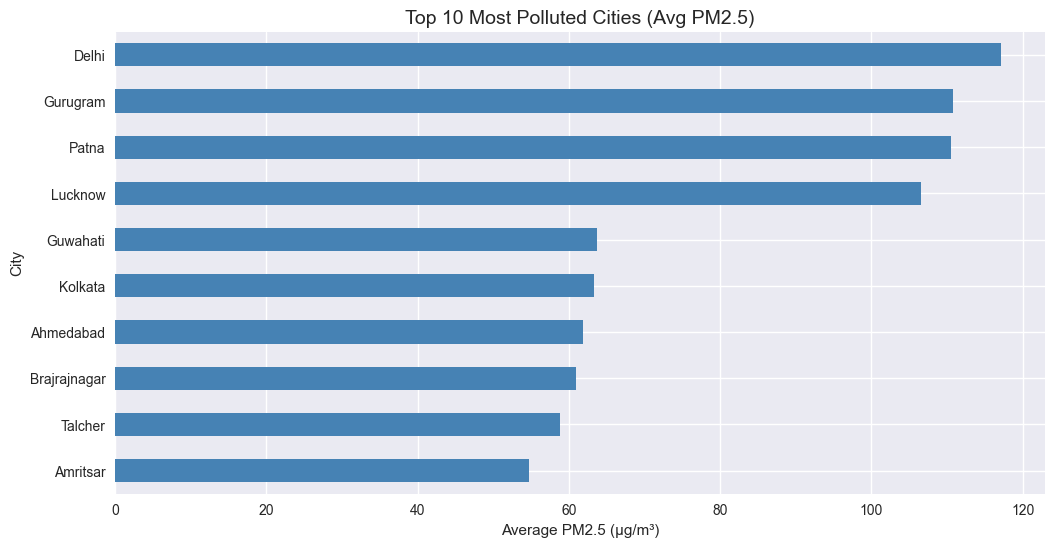

In [ ]:
# Plot 6 — Top 10 most polluted cities
city_avg = df.groupby('City')['PM2.5'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
city_avg.head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Polluted Cities (Avg PM2.5)', fontsize=14)
plt.xlabel('Average PM2.5 (µg/m³)')
plt.gca().invert_yaxis()
plt.show()

Key Insights:- 
1) Data Preparation
2) Figure size: Creates a plot 12 wide, 6 tall — wider to fit city names clearly
3) Horizontal Bar Chart:
   - .head(10) → takes only top 10 most polluted cities
   - kind='barh' → horizontal bar chart — better for city names as they're long
   - color='steelblue' → bar color

4)  Labels: Standard title and x axis label, No ylabel needed — city names are already on y axis
5) Invert Y axis:
   - gca() → get current axes
   - invert_yaxis() → flips the y axis so highest value city appears at top


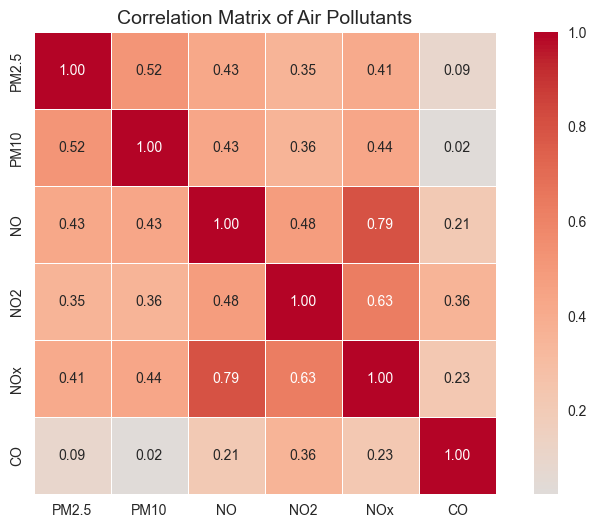

Observation: PM2.5 and PM10 show strong positive
correlation, indicating common emission sources.


In [ ]:
# Plot 7 — Correlation heatmap
cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO']
corr_cols = [c for c in cols if c in df.columns]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',cmap='coolwarm', center=0,square=True, linewidths=0.5)
plt.title('Correlation Matrix of Air Pollutants', fontsize=14)
plt.show()
print("Observation: PM2.5 and PM10 show strong positive")
print("correlation, indicating common emission sources.")

Key Insights:-
1) Define columns: Manually selects only 6 key pollutant columns for correlation ( Not using all 13 columns — keeps heatmap clean and readable )
2) Safety check: 
   - corr_cols = [c for c in cols if c in df.columns] -> This is a list comprehension that checks if each column actually exists in the dataframe
   - Prevents errors if any column name was mistyped or doesn't exist and only keeps columns that are confirmed present in df.
3)  Correlation Matrix:
   - .corr() → calculates Pearson correlation between every pair of columns
   - Result is a 6x6 matrix where each cell shows correlation between two pollutants
   - Values range from -1 to +1:
       1) +1 → perfect positive correlation
       2) 0 → no correlation
       3) -1 → perfect negative correlation

4)  Heatmap:
   - annot=True → shows the actual number inside each cell
   - fmt='.2f' → formats numbers to 2 decimal places
   - cmap='coolwarm' → color scheme: 
        1) Dark red = strong positive correlation
        2) White = no correlation
        3) Dark blue = strong negative correlation
   - center=0 → white color is centered at zero correlation
   - square=True → makes each cell perfectly square
   - linewidths=0.5 → thin white lines separating cells


In [ ]:
# Statistical test — Is Winter PM2.5 significantly 
# higher than Summer? (Hypothesis Testing)
winter = df[df['Season']=='Winter']['PM2.5'].dropna()
summer = df[df['Season']=='Summer']['PM2.5'].dropna()

t_stat, p_value = stats.ttest_ind(winter, summer)

print("="*50)
print("HYPOTHESIS TEST: Winter vs Summer PM2.5")
print("="*50)
print(f"Winter Mean PM2.5: {winter.mean():.2f} µg/m³")
print(f"Summer Mean PM2.5: {summer.mean():.2f} µg/m³")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print()
if p_value < 0.05:
    print("✅ Result: Statistically significant difference!")
    print("Winter PM2.5 is significantly higher than Summer.")
else:
    print("Result: No significant difference found.")
print("="*50)


HYPOTHESIS TEST: Winter vs Summer PM2.5
Winter Mean PM2.5: 92.14 µg/m³
Summer Mean PM2.5: 40.49 µg/m³
T-statistic: 54.8570
P-value: 0.000000

✅ Result: Statistically significant difference!
Winter PM2.5 is significantly higher than Summer.


Key Insights:- 

1)  Extract Season Data:
   - Filters dataframe to get only Winter rows and extracts PM2.5 values, same for Summer rows
   - .dropna() → removes missing values before testing
   - Now we have two separate groups to compare

2) T-Test:
   - ttest_ind → Independent samples T-test
   - Compares means of two independent groups — Winter vs Summer
   - Returns two values:
       1) t_stat → how many standard deviations apart the two means are
       2) p_value → probability that this difference happened by random chance

3) Formatting output:
   - "="*50 → prints 50 equal signs as a divider line for clean output
   - Just for visual formatting.
   - f"..." → f-string formatting
   - :.2f → round to 2 decimal places
   - :.4f → round to 4 decimal places
   - :.6f → round to 6 decimal places

4) Decision Logic:

## Key Findings

1. PM2.5 follows a right-skewed, Log-Normal distribution
   — consistent with environmental data literature

2. Strong seasonal pattern — Winter months show 2–3x 
   higher PM2.5 compared to monsoon months

3. Statistical test confirms Winter PM2.5 is significantly
   higher than Summer (p < 0.05)

4. High correlation between PM2.5 and PM10 suggests 
   common pollution sources (vehicular + industrial)

5. Delhi and northern cities consistently show the 
   highest PM2.5 levels

## Future Scope
- Time series forecasting using ARIMA/SARIMA
- Spatiotemporal modelling (as in Kayal et al., 2024)
- Survival analysis on "days exceeding safe limit"